# Decision Tree Model Development and Optimization

**Module:** IT3051 – Fundamentals of Data Mining  
**Project:** Hotel Booking Cancellation Prediction  
**Member:** Member 02  
**Algorithm:** Decision Tree Classifier  

## Objective

The objective of this notebook is to develop, evaluate, and optimize a Decision Tree classification model for predicting hotel booking cancellations.

The Decision Tree is included because it can capture nonlinear relationships and interactions between features. However, unrestricted Decision Trees can overfit the training data. Therefore, this notebook evaluates a baseline Decision Tree, investigates overfitting using training and cross-validation performance, tunes important complexity-related hyperparameters, and evaluates the selected configuration on the final held-out test set.

## 1. Imports and Dataset Loading

The common feature-engineered dataset is loaded for Decision Tree model development. The target variable is `is_canceled`, where 1 represents a cancelled booking and 0 represents a non-cancelled booking.

The dataset is not modified in this notebook because all team members must use the same feature-engineered dataset for a fair model comparison.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (119390, 35)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,is_family,service_score,customer_history,room_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,0,2.0,0,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,0,2.0,0,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,1,1.0,0,0,0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,1,1.0,0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,2,2.0,0,1,0,0


In [3]:
print("Target column exists:", "is_canceled" in df.columns)

print("\nTarget distribution:")
print(df["is_canceled"].value_counts())

print("\nTarget percentage distribution:")
print(df["is_canceled"].value_counts(normalize=True).mul(100).round(2))

Target column exists: True

Target distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target percentage distribution:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


In [4]:
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (119390, 34)
Target shape: (119390,)


In [6]:
categorical_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Number of categorical features:", len(categorical_cols))
print("Number of numerical features:", len(numerical_cols))

print("\nCategorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

Number of categorical features: 10
Number of numerical features: 24

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'is_family', 'service_score', 'customer_history', 'room_changed']


## 2. Train-Test Split and Cross-Validation Setup

The dataset is divided into 80% training data and 20% final hold-out test data using stratified sampling. A fixed random state of 42 is used for reproducibility.

Stratification preserves the proportion of cancelled and non-cancelled bookings in both subsets. The final test set is kept separate from model development and hyperparameter tuning.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\nTraining target distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Training records: 95512
Testing records: 23878

Training target distribution (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64

Testing target distribution (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print(cv)

Cross-validation strategy:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 3. Decision Tree Preprocessing Pipeline

The Decision Tree requires categorical features to be converted into numerical form. Therefore, One-Hot Encoding is applied to categorical predictors with `handle_unknown="ignore"`.

Numerical predictors are passed through without scaling because Decision Trees split features using threshold-based rules and are not sensitive to differences in feature scale.

The preprocessing steps and Decision Tree classifier are combined in a Pipeline to ensure that preprocessing is fitted correctly within each cross-validation training fold and to reduce the risk of data leakage.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "numerical",
            "passthrough",
            numerical_cols
        )
    ]
)

print("Decision Tree preprocessor created successfully.")

Decision Tree preprocessor created successfully.


In [11]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

print("Baseline Decision Tree pipeline created successfully.")

Baseline Decision Tree pipeline created successfully.


## 4. Baseline Decision Tree Evaluation

The unrestricted Decision Tree is first evaluated as a baseline before hyperparameter tuning.

Five-fold Stratified Cross-Validation is performed only on the training portion of the dataset. Accuracy, Precision, Recall, F1-score, and ROC-AUC are recorded using the same evaluation protocol as the other team models.

Training scores are also recorded and compared with cross-validation scores to investigate whether the unrestricted Decision Tree is overfitting.

In [12]:
from sklearn.model_selection import cross_validate
import time

In [13]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Evaluation metrics:", list(scoring.keys()))

Evaluation metrics: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


In [14]:
start_time = time.time()

baseline_cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

baseline_cv_time = time.time() - start_time

print(f"Baseline 5-fold CV completed in {baseline_cv_time:.2f} seconds.")

Baseline 5-fold CV completed in 79.75 seconds.


In [15]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

baseline_summary = []

for metric in metrics:
    train_scores = baseline_cv_results[f"train_{metric}"]
    cv_scores = baseline_cv_results[f"test_{metric}"]

    baseline_summary.append({
        "Metric": metric.upper(),
        "Train Mean": train_scores.mean(),
        "Train Std": train_scores.std(),
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Train-CV Gap": train_scores.mean() - cv_scores.mean()
    })

baseline_summary_df = pd.DataFrame(baseline_summary)

baseline_summary_df.round(4)

,Metric,Train Mean,Train Std,CV Mean,CV Std,Train-CV Gap
0,ACCURACY,0.9965,0.0000,0.8599,0.0033,0.1366
1,PRECISION,0.9973,0.0002,0.8083,0.0059,0.1891
2,RECALL,0.9933,0.0002,0.8154,0.0038,0.1780
3,F1,0.9953,0.0001,0.8118,0.0041,0.1835
4,ROC_AUC,1.0000,0.0000,0.8528,0.0031,0.1472


### Baseline Interpretation

The baseline unrestricted Decision Tree achieved strong cross-validation performance, with a mean CV Accuracy of 0.8599, Recall of 0.8154, F1-score of 0.8118, and ROC-AUC of 0.8528.

However, the training scores were substantially higher than the cross-validation scores. Training Accuracy reached 0.9965 and training F1 reached 0.9953, compared with CV Accuracy of 0.8599 and CV F1 of 0.8118.

The large gaps between training and cross-validation performance indicate that the unrestricted Decision Tree is overfitting the training data. Therefore, hyperparameter tuning will focus on controlling tree complexity using parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf`.

## 5. Hyperparameter Tuning

The baseline Decision Tree showed substantial overfitting, with training performance considerably higher than cross-validation performance.

Therefore, hyperparameter tuning is performed to control the complexity of the Decision Tree and improve its ability to generalize to unseen data.

GridSearchCV is applied only to the training data using the same 5-fold Stratified Cross-Validation strategy. The final hold-out test set is not used during hyperparameter selection.

F1-score is used as the primary optimization metric because it balances Precision and Recall for cancellation prediction.

In [16]:
from sklearn.model_selection import GridSearchCV

In [17]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}

total_combinations = (
    len(param_grid["model__criterion"]) *
    len(param_grid["model__max_depth"]) *
    len(param_grid["model__min_samples_split"]) *
    len(param_grid["model__min_samples_leaf"]) *
    len(param_grid["model__class_weight"])
)

print("Hyperparameter combinations:", total_combinations)
print("Total CV fits:", total_combinations * 5)

Hyperparameter combinations: 180
Total CV fits: 900


In [18]:
grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("GridSearchCV configured successfully.")

GridSearchCV configured successfully.


### Running GridSearchCV

The configured hyperparameter combinations are evaluated using 5-fold Stratified Cross-Validation on the training data only.

F1-score is used to select the best configuration. The total tuning time is also recorded to evaluate the computational cost of optimization.

In [19]:
start_time = time.time()

grid_search.fit(X_train, y_train)

tuning_time = time.time() - start_time

print(f"\nGridSearchCV completed in {tuning_time:.2f} seconds.")
print(f"GridSearchCV completed in {tuning_time / 60:.2f} minutes.")

print("\nBest hyperparameters:")
print(grid_search.best_params_)

print(f"\nBest CV F1-score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits

GridSearchCV completed in 3691.50 seconds.
GridSearchCV completed in 61.52 minutes.

Best hyperparameters:
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best CV F1-score: 0.8225


## 6. Tuned Decision Tree Cross-Validation Evaluation

GridSearchCV selected the best Decision Tree configuration using F1-score as the optimization metric.

The selected configuration is now evaluated using the same 5-fold Stratified Cross-Validation strategy and the same five metrics used for the baseline model. Training scores are also recorded to determine whether hyperparameter tuning reduced overfitting.

In [20]:
best_model = grid_search.best_estimator_

print("Selected Decision Tree configuration:")
print(grid_search.best_params_)

Selected Decision Tree configuration:
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


In [21]:
import time
import numpy as np
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

start_time = time.time()

fold_results = {
    "train_accuracy": [], "test_accuracy": [],
    "train_precision": [], "test_precision": [],
    "train_recall": [], "test_recall": [],
    "train_f1": [], "test_f1": [],
    "train_roc_auc": [], "test_roc_auc": []
}

total_folds = cv.get_n_splits()

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    print(f"Running fold {fold}/{total_folds}...")

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    model = clone(best_model)
    model.fit(X_fold_train, y_fold_train)

    train_pred = model.predict(X_fold_train)
    val_pred = model.predict(X_fold_val)

    train_prob = model.predict_proba(X_fold_train)[:, 1]
    val_prob = model.predict_proba(X_fold_val)[:, 1]

    fold_results["train_accuracy"].append(
        accuracy_score(y_fold_train, train_pred)
    )
    fold_results["test_accuracy"].append(
        accuracy_score(y_fold_val, val_pred)
    )

    fold_results["train_precision"].append(
        precision_score(y_fold_train, train_pred, zero_division=0)
    )
    fold_results["test_precision"].append(
        precision_score(y_fold_val, val_pred, zero_division=0)
    )

    fold_results["train_recall"].append(
        recall_score(y_fold_train, train_pred, zero_division=0)
    )
    fold_results["test_recall"].append(
        recall_score(y_fold_val, val_pred, zero_division=0)
    )

    fold_results["train_f1"].append(
        f1_score(y_fold_train, train_pred, zero_division=0)
    )
    fold_results["test_f1"].append(
        f1_score(y_fold_val, val_pred, zero_division=0)
    )

    fold_results["train_roc_auc"].append(
        roc_auc_score(y_fold_train, train_prob)
    )
    fold_results["test_roc_auc"].append(
        roc_auc_score(y_fold_val, val_prob)
    )

    print(f"✓ Fold {fold}/{total_folds} completed")

tuned_cv_results = {
    key: np.array(values)
    for key, values in fold_results.items()
}

tuned_cv_time = time.time() - start_time

print("\nAll 5 folds completed!")
print(f"Tuned model 5-fold CV completed in {tuned_cv_time:.2f} seconds.")

Running fold 1/5...
✓ Fold 1/5 completed
Running fold 2/5...
✓ Fold 2/5 completed
Running fold 3/5...
✓ Fold 3/5 completed
Running fold 4/5...
✓ Fold 4/5 completed
Running fold 5/5...
✓ Fold 5/5 completed

All 5 folds completed!
Tuned model 5-fold CV completed in 77.50 seconds.


In [22]:
tuned_summary = []

for metric in metrics:
    train_scores = tuned_cv_results[f"train_{metric}"]
    cv_scores = tuned_cv_results[f"test_{metric}"]

    tuned_summary.append({
        "Metric": metric.upper(),
        "Train Mean": train_scores.mean(),
        "Train Std": train_scores.std(),
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Train-CV Gap": train_scores.mean() - cv_scores.mean()
    })

tuned_summary_df = pd.DataFrame(tuned_summary)

tuned_summary_df.round(4)

,Metric,Train Mean,Train Std,CV Mean,CV Std,Train-CV Gap
0,ACCURACY,0.9216,0.0018,0.8617,0.0022,0.0598
1,PRECISION,0.8585,0.0035,0.7840,0.0031,0.0744
2,RECALL,0.9439,0.0029,0.8651,0.0064,0.0789
3,F1,0.8992,0.0022,0.8225,0.0032,0.0766
4,ROC_AUC,0.9822,0.0004,0.9097,0.0019,0.0725


## 7. Baseline vs Tuned Decision Tree Comparison

The baseline and tuned Decision Tree models are compared using the same 5-fold Stratified Cross-Validation metrics.

The comparison evaluates whether hyperparameter tuning improved generalization and reduced the overfitting observed in the unrestricted baseline Decision Tree.

In [23]:
comparison_rows = []

for metric in metrics:
    baseline_cv_mean = baseline_cv_results[f"test_{metric}"].mean()
    tuned_cv_mean = tuned_cv_results[f"test_{metric}"].mean()

    comparison_rows.append({
        "Metric": metric.upper(),
        "Baseline CV": baseline_cv_mean,
        "Tuned CV": tuned_cv_mean,
        "Change": tuned_cv_mean - baseline_cv_mean
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df.round(4)

,Metric,Baseline CV,Tuned CV,Change
0,ACCURACY,0.8599,0.8617,0.0018
1,PRECISION,0.8083,0.7840,-0.0242
2,RECALL,0.8154,0.8651,0.0497
3,F1,0.8118,0.8225,0.0108
4,ROC_AUC,0.8528,0.9097,0.0569


In [24]:
overfitting_comparison = []

for metric in metrics:
    baseline_gap = (
        baseline_cv_results[f"train_{metric}"].mean()
        - baseline_cv_results[f"test_{metric}"].mean()
    )

    tuned_gap = (
        tuned_cv_results[f"train_{metric}"].mean()
        - tuned_cv_results[f"test_{metric}"].mean()
    )

    overfitting_comparison.append({
        "Metric": metric.upper(),
        "Baseline Train-CV Gap": baseline_gap,
        "Tuned Train-CV Gap": tuned_gap,
        "Gap Reduction": baseline_gap - tuned_gap
    })

overfitting_comparison_df = pd.DataFrame(overfitting_comparison)

overfitting_comparison_df.round(4)

,Metric,Baseline Train-CV Gap,Tuned Train-CV Gap,Gap Reduction
0,ACCURACY,0.1366,0.0598,0.0768
1,PRECISION,0.1891,0.0744,0.1146
2,RECALL,0.1780,0.0789,0.0991
3,F1,0.1835,0.0766,0.1069
4,ROC_AUC,0.1472,0.0725,0.0747


### Baseline vs Tuned Interpretation

Hyperparameter tuning improved the generalization of the Decision Tree and substantially reduced the overfitting observed in the unrestricted baseline model.

The mean cross-validation F1-score increased from approximately 0.8118 to 0.8225, while Recall increased from approximately 0.8154 to 0.8651. ROC-AUC also improved considerably from approximately 0.8528 to 0.9097.

Precision decreased from approximately 0.8083 to 0.7840, indicating a Precision-Recall trade-off. The tuned model identifies a greater proportion of actual cancellations, but some additional non-cancelled bookings may consequently be classified as cancellations.

Most importantly, the training-to-cross-validation F1 gap decreased from approximately 0.1835 for the unrestricted baseline tree to approximately 0.0766 for the tuned tree. This provides evidence that controlling tree complexity reduced overfitting.

Therefore, the tuned Decision Tree configuration is selected for final hold-out evaluation.

## 8. Final Decision Tree Configuration

Based on the training-only GridSearchCV results and the baseline-versus-tuned cross-validation comparison, the tuned Decision Tree configuration is selected and frozen for final evaluation.

The selected hyperparameters are:

- `criterion = "gini"`
- `max_depth = 20`
- `min_samples_split = 2`
- `min_samples_leaf = 1`
- `class_weight = "balanced"`
- `random_state = 42`

The tuned model achieved a higher cross-validation F1-score and ROC-AUC than the unrestricted baseline while substantially reducing the training-to-cross-validation performance gap. Therefore, this configuration is selected for final hold-out evaluation.

No further hyperparameter changes will be made based on the final test-set results.

In [25]:
final_model = grid_search.best_estimator_

print("Final Decision Tree configuration frozen.")
print("\nSelected hyperparameters:")
print(grid_search.best_params_)

Final Decision Tree configuration frozen.

Selected hyperparameters:
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


## 9. Final Hold-Out Test Evaluation

After completing model selection and freezing the tuned Decision Tree configuration, the model is evaluated on the independent 20% hold-out test set.

The test set was not used during baseline evaluation, hyperparameter tuning, or model selection. Therefore, this evaluation provides an independent estimate of how the selected Decision Tree generalizes to unseen booking records.

The final evaluation reports Accuracy, Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix.

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [27]:
start_time = time.time()

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

test_prediction_time = time.time() - start_time

print(f"Predictions completed in {test_prediction_time:.2f} seconds.")

Predictions completed in 0.88 seconds.


In [28]:
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

print("FINAL HOLD-OUT TEST RESULTS")
print("-" * 40)
print(f"Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Precision: {test_precision:.4f} ({test_precision * 100:.2f}%)")
print(f"Recall   : {test_recall:.4f} ({test_recall * 100:.2f}%)")
print(f"F1-score : {test_f1:.4f} ({test_f1 * 100:.2f}%)")
print(f"ROC-AUC  : {test_roc_auc:.4f} ({test_roc_auc * 100:.2f}%)")

FINAL HOLD-OUT TEST RESULTS
----------------------------------------
Accuracy : 0.8663 (86.63%)
Precision: 0.7934 (79.34%)
Recall   : 0.8641 (86.41%)
F1-score : 0.8273 (82.73%)
ROC-AUC  : 0.9134 (91.34%)


In [29]:
print("CLASSIFICATION REPORT")
print("-" * 40)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Not Cancelled", "Cancelled"],
        zero_division=0
    )
)

CLASSIFICATION REPORT
----------------------------------------
               precision    recall  f1-score   support

Not Cancelled       0.92      0.87      0.89     15033
    Cancelled       0.79      0.86      0.83      8845

     accuracy                           0.87     23878
    macro avg       0.85      0.87      0.86     23878
 weighted avg       0.87      0.87      0.87     23878



## 10. Confusion Matrix and ROC Curve

The final Decision Tree predictions are further evaluated using a Confusion Matrix and ROC Curve.

The Confusion Matrix shows the exact numbers of correctly and incorrectly classified bookings, while the ROC Curve illustrates the model's ability to distinguish between cancelled and non-cancelled bookings across different classification thresholds.

In [30]:
cm = confusion_matrix(y_test, y_test_pred)

tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX VALUES")
print("-" * 40)
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

print("\nTotal test records:", tn + fp + fn + tp)

CONFUSION MATRIX VALUES
----------------------------------------
True Negatives  (TN): 13043
False Positives (FP): 1990
False Negatives (FN): 1202
True Positives  (TP): 7643

Total test records: 23878


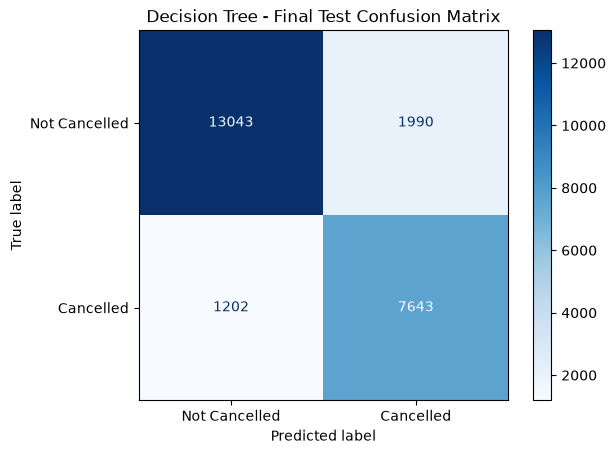

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Cancelled", "Cancelled"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Decision Tree - Final Test Confusion Matrix")
plt.show()

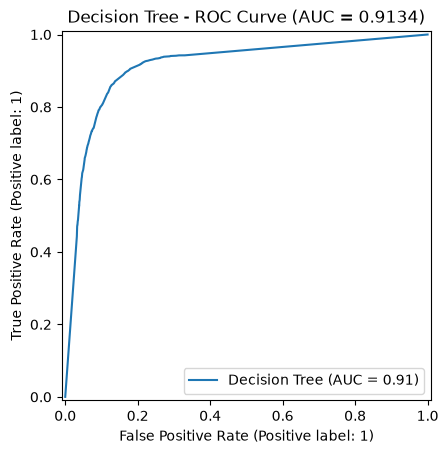

In [32]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob,
    name="Decision Tree"
)

plt.title(
    f"Decision Tree - ROC Curve (AUC = {test_roc_auc:.4f})"
)
plt.show()

## 11. Final Decision Tree Interpretation

### Final Performance

The tuned Decision Tree demonstrated strong performance on the independent hold-out test set:

- **Accuracy:** 0.8663 (86.63%)
- **Precision:** 0.7934 (79.34%)
- **Recall:** 0.8641 (86.41%)
- **F1-score:** 0.8273 (82.73%)
- **ROC-AUC:** 0.9134 (91.34%)

These final test results are close to the tuned cross-validation results. For example, the mean cross-validation F1-score was 0.8225 compared with a final test F1-score of 0.8273, while cross-validation Recall was 0.8651 compared with final test Recall of 0.8641. This consistency indicates that the tuned Decision Tree generalizes well to the independent test data.

### Effect of Hyperparameter Tuning

The unrestricted baseline Decision Tree showed substantial overfitting. Its training F1-score was approximately 0.9953, while its mean cross-validation F1-score was 0.8118, producing a large training-to-validation gap of approximately 0.1835.

After hyperparameter tuning, the selected Decision Tree used a maximum depth of 20 together with balanced class weights. The tuned training F1-score decreased to approximately 0.8992 while the cross-validation F1-score increased to 0.8225. Consequently, the F1 training-to-validation gap decreased to approximately 0.0766.

This demonstrates that controlling tree complexity substantially reduced overfitting while improving generalization performance.

### Prediction Errors

The final Confusion Matrix produced:

- **True Negatives (TN): 13,043**
- **False Positives (FP): 1,990**
- **False Negatives (FN): 1,202**
- **True Positives (TP): 7,643**

The model correctly detected 7,643 cancelled bookings while missing 1,202 actual cancellations. It also incorrectly classified 1,990 non-cancelled bookings as cancellations.

The relatively high Recall of 86.41% indicates that the model successfully identifies a large proportion of actual cancellations. However, this comes with a Precision-Recall trade-off, because some non-cancelled bookings are incorrectly flagged as cancellations.

### Strengths

- Captures nonlinear relationships and interactions between booking features.
- Achieved strong Recall and F1-score for cancellation prediction.
- Achieved a final ROC-AUC of 0.9134, indicating strong discrimination between cancelled and non-cancelled bookings.
- Hyperparameter tuning substantially reduced the overfitting observed in the unrestricted baseline tree.
- Decision-tree rules can be interpreted more directly than many complex ensemble approaches.

### Limitations

- Some overfitting remains because the tuned training scores are still higher than the cross-validation scores.
- Higher Recall is accompanied by lower Precision, resulting in additional false cancellation alerts.
- A depth-20 Decision Tree can still be relatively complex and may be less interpretable than a much smaller tree.
- A single Decision Tree can be more sensitive to variations in training data than ensemble tree methods such as Random Forest.

### Recommendation

The tuned Decision Tree should be retained as a strong candidate for the team's final model comparison. It performed substantially better than the unrestricted baseline in terms of generalization, achieved strong Recall, F1-score and ROC-AUC, and produced final test performance that was consistent with cross-validation performance.

However, the Decision Tree should not yet be declared the overall final project model. Its results must first be compared fairly with Logistic Regression, Random Forest, and K-Nearest Neighbors using the common team evaluation protocol.

## 12. Save Result Summary for Team Comparison

A standardized summary of the tuned Decision Tree results is saved for the team's final model comparison.

The summary includes the selected hyperparameters, tuned cross-validation results, final hold-out test results, confusion matrix values, runtime information, and the main strengths and limitations of the model.

In [34]:
decision_tree_results = pd.DataFrame([{
    "member": "Member 02",
    "model": "Decision Tree",
    "version": "Tuned",

    # Best hyperparameters
    "best_criterion": grid_search.best_params_["model__criterion"],
    "best_max_depth": grid_search.best_params_["model__max_depth"],
    "best_min_samples_split": grid_search.best_params_["model__min_samples_split"],
    "best_min_samples_leaf": grid_search.best_params_["model__min_samples_leaf"],
    "best_class_weight": grid_search.best_params_["model__class_weight"],

    # Tuned cross-validation results
    "cv_accuracy_mean": tuned_cv_results["test_accuracy"].mean(),
    "cv_accuracy_std": tuned_cv_results["test_accuracy"].std(),

    "cv_precision_mean": tuned_cv_results["test_precision"].mean(),
    "cv_precision_std": tuned_cv_results["test_precision"].std(),

    "cv_recall_mean": tuned_cv_results["test_recall"].mean(),
    "cv_recall_std": tuned_cv_results["test_recall"].std(),

    "cv_f1_mean": tuned_cv_results["test_f1"].mean(),
    "cv_f1_std": tuned_cv_results["test_f1"].std(),

    "cv_roc_auc_mean": tuned_cv_results["test_roc_auc"].mean(),
    "cv_roc_auc_std": tuned_cv_results["test_roc_auc"].std(),

    # Final hold-out test results
    "final_test_accuracy": test_accuracy,
    "final_test_precision": test_precision,
    "final_test_recall": test_recall,
    "final_test_f1": test_f1,
    "final_test_roc_auc": test_roc_auc,

    # Confusion matrix
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,

    # Runtime
    "baseline_cv_time_seconds": baseline_cv_time,
    "tuning_time_seconds": tuning_time,
    "tuned_cv_time_seconds": tuned_cv_time,

    # Interpretation
    "main_strength": (
        "Strong recall, F1 and ROC-AUC with substantially reduced "
        "overfitting after tuning."
    ),

    "main_weakness": (
        "Precision decreased after tuning and some overfitting remains."
    ),

    "overfitting_observation": (
        "F1 Train-CV gap reduced from approximately 0.1835 "
        "to 0.0766 after tuning."
    ),

    "recommend_as_final_candidate": (
        "Yes - retain for team comparison, but do not select as the "
        "overall final model until all four algorithms are compared."
    )
}])

decision_tree_results.T

,0
member,Member 02
model,Decision Tree
version,Tuned
best_criterion,gini
best_max_depth,20
best_min_samples_split,2
best_min_samples_leaf,1
best_class_weight,balanced
cv_accuracy_mean,0.861745
cv_accuracy_std,0.002208


In [35]:
results_path = "../results/decision_tree_results.csv"

decision_tree_results.to_csv(
    results_path,
    index=False
)

print(f"Decision Tree results saved successfully to: {results_path}")

Decision Tree results saved successfully to: ../results/decision_tree_results.csv


In [36]:
saved_results = pd.read_csv(
    "../results/decision_tree_results.csv"
)

print("Saved result shape:", saved_results.shape)
saved_results.T

Saved result shape: (1, 34)


,0
member,Member 02
model,Decision Tree
version,Tuned
best_criterion,gini
best_max_depth,20
best_min_samples_split,2
best_min_samples_leaf,1
best_class_weight,balanced
cv_accuracy_mean,0.861745
cv_accuracy_std,0.002208
